### Pracitce Exercise (Decision Tree Regression)

In [58]:
from pathlib import Path
import sys

current_dir = Path.cwd()
project_root = current_dir.parent.absolute()

sys.path.insert(0,str(project_root))

from config import DS_DTR

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [60]:
#loadin the dataset
df = pd.read_csv(DS_DTR)

print(f'Shape of the Dataset: {df.shape}')
print(f'Missing data in each column:\n{df.isnull().sum()}')

Shape of the Dataset: (30, 6)
Missing data in each column:
Year          0
Mileage       0
EngineSize    0
Horsepower    0
FuelType      0
Price         0
dtype: int64


In [61]:
#dataset
df.head()

,Year,Mileage,EngineSize,Horsepower,FuelType,Price
0,2020,5000,1.5,120,0,22000
1,2018,25000,2.0,150,0,18500
2,2015,60000,1.8,140,0,12000
3,2021,2000,2.5,200,0,35000
4,2017,40000,1.6,130,0,14500


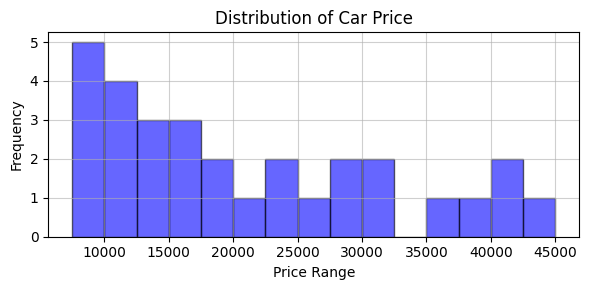

In [62]:
#histogram of the price col
plt.figure(figsize=(6,3))
plt.hist(df['Price'],bins=15,color='blue',alpha=0.6,edgecolor='black')
plt.xlabel('Price Range')
plt.ylabel('Frequency')
plt.title('Distribution of Car Price')
plt.tight_layout()
plt.grid(True,alpha=0.6)
plt.show()

<Figure size 600x800 with 0 Axes>

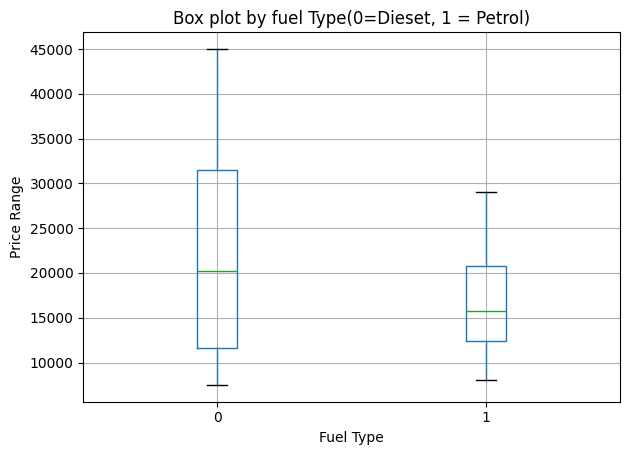

In [63]:
#Boxplot by Fuel Type
plt.figure(figsize=(6,8))
df.boxplot(column='Price',by='FuelType',grid='True')
plt.xlabel('Fuel Type')
plt.ylabel('Price Range')
plt.title('Box plot by fuel Type(0=Dieset, 1 = Petrol)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [64]:
X = df.drop('Price',axis=1)
y = df[['Price']].values

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [66]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

dt = DecisionTreeRegressor(max_depth=4,random_state=42)
dt.fit(X_train,y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

In [67]:
#predictions

y_pred_test = dt.predict(X_test)

In [68]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
R2_Score = r2_score(y_pred_test,y_test)
mae = mean_absolute_error(y_pred_test,y_test)
mse = np.sqrt(mean_squared_error(y_pred_test,y_test))

print(f'R2 Score: {R2_Score:.2f}\nMean Absolute Error: {mae:.2f}\nMean Squared Error: {mse:.2f}')

R2 Score: 0.97
Mean Absolute Error: 1291.67
Mean Squared Error: 1648.86


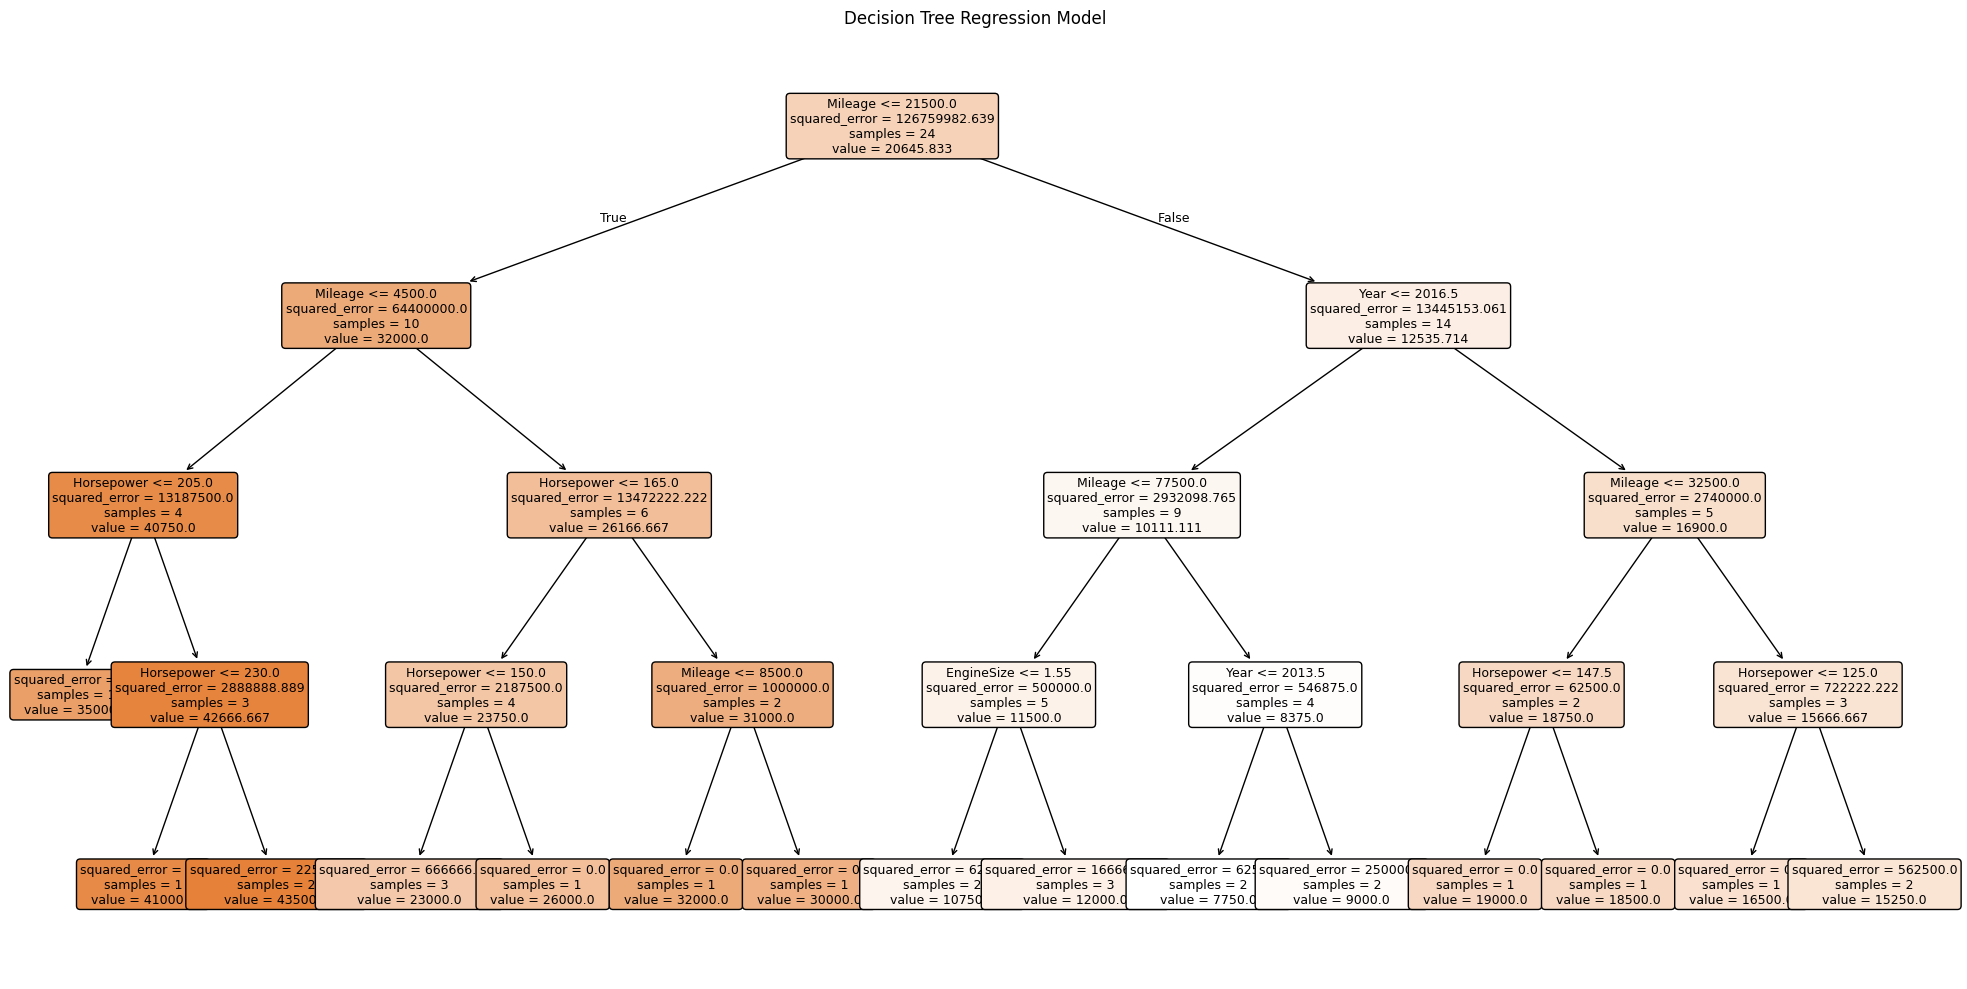

In [69]:
#Visualize the Tree
plt.figure(figsize=(20,10))
plot_tree(dt,feature_names=X.columns.tolist(),rounded=True,filled=True,fontsize=9)
plt.title('Decision Tree Regression Model')
plt.tight_layout()
plt.show()

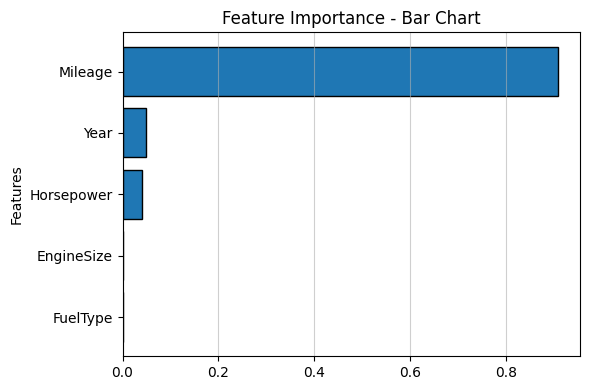

In [75]:
# Feature Importance
importance = dt.feature_importances_
df_imp = pd.DataFrame({'Feature':X.columns,'Importance':importance})
df_imp = df_imp.sort_values('Importance',ascending=True)
plt.figure(figsize=(6,4))
plt.barh(df_imp['Feature'],df_imp['Importance'],edgecolor='black')
plt.title('Feature Importance - Bar Chart')
plt.ylabel('Features')
plt.grid(True,alpha=0.6,axis='x')
plt.tight_layout()
plt.show()

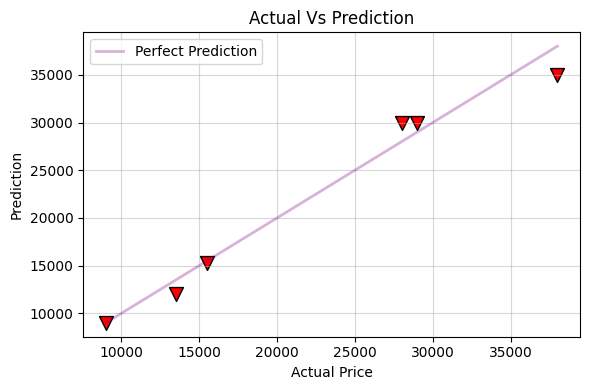

In [78]:
#actual vs prediction
plt.figure(figsize=(6,4))
min_V = min(y_pred_test.min(),y_test.min())
max_V = max(y_pred_test.max(),y_test.max())
plt.scatter(y_test, y_pred_test,color='r',marker='v',s=100,edgecolors='black')
plt.plot([min_V,max_V],[min_V,max_V],color='purple',linewidth=2,alpha=0.3,label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Prediction')
plt.title('Actual Vs Prediction')
plt.legend()
plt.tight_layout()
plt.grid(True,alpha=0.5)
plt.show()

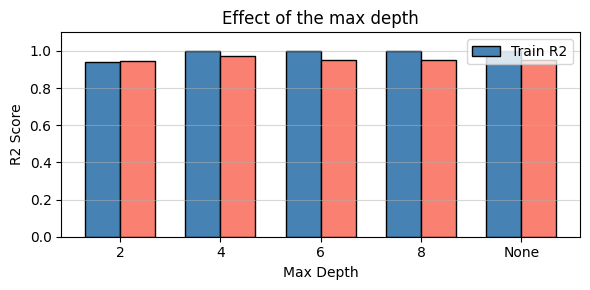

In [82]:
#comparing max depth
depth = [2,4,6,8,None]
train_R2_score = []
test_R2_score = []

for d in depth:
    dtr = DecisionTreeRegressor(max_depth=d, random_state=42)
    dtr.fit(X_train,y_train)

    train_R2_score.append(r2_score(y_train,dtr.predict(X_train)))
    test_R2_score.append(r2_score(y_test,dtr.predict(X_test)))

plt.figure(figsize=(6,3))
X_labels = [str(d) if d else 'None' for d in depth]
X_pos = np.arange(len(depth))
width=0.35
plt.bar(X_pos - width/2, train_R2_score,width,color='steelblue',label='Train R2',edgecolor='black')
plt.bar(X_pos + width/2 , test_R2_score, width, color='salmon',edgecolor='black')
plt.xticks(X_pos,X_labels)
plt.xlabel('Max Depth')
plt.ylabel('R2 Score')
plt.title('Effect of the max depth')
plt.legend()
plt.grid(True,alpha=0.5,axis='y')
plt.ylim(0,1.1)
plt.tight_layout()
plt.show()
